## Mooring Report, Lake Zug, 2026.04.09

All moorings retreived.

In [1]:
# imports
import ewgreaders as ewg
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
lake = 'Zug'
year = '2026'
date = '20260409'

### LZC

In [3]:
location = 'LZC'

In [4]:
mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

KeyError: 'depth'

In [ ]:
# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')

#### ADCPs

In [32]:
all_adcp = []
for adcp in adcps:
    areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
    fpath = areader.locate_data_file('L0')
    ds = areader.load_from_L0()
    ds = ds.expand_dims(serial_id=[ds.attrs['serialnum']])
    areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
    ds = areader.range_to_depth(ds)
    ds['range'] = ds['range'].round(0)
    ds = areader.run_qa(ds)
    ds = ds.sel(time=slice(t_start, t_end))
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_combined = xr.concat(all_adcp_aligned, dim='range')
ds_combined = ds_combined.sortby('range')
ds_combined = ds_combined.groupby('range').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(79, 84)
full_range = np.sort(np.concatenate([ds_combined.range.values, gap]))
ds_full = ds_combined.reindex(range=full_range)

# drop range bins with dubious data
bad_ranges = [78, 138, 139, 140]
ds_full = ds_full.drop_sel(range=bad_ranges)


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZC/L0\3U16549.000 ...


C:\Users\herremha\AppData\Local\Temp\ipykernel_32128\726052738.py:19: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'serial_id' ('serial_id',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(all_adcp_aligned, dim='range')


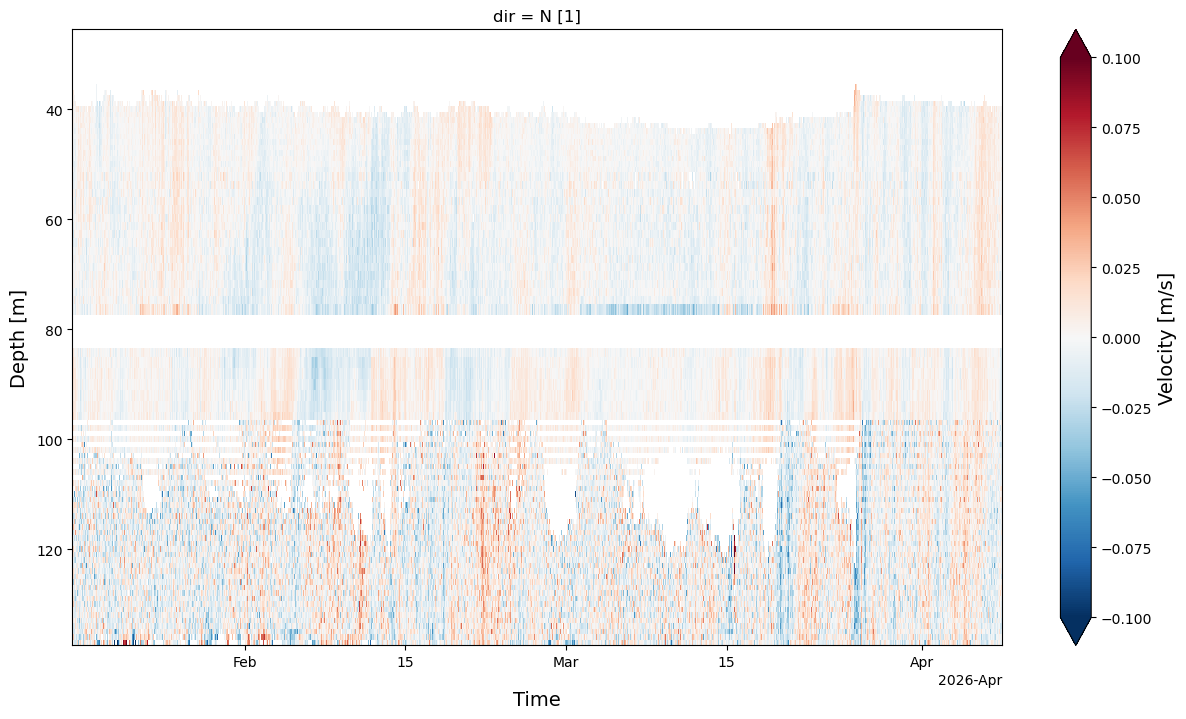

In [46]:
fig, ax = plt.subplots(figsize=(15, 8))

# velocity
pc = ds_full.vel.sel(dir='N').mean(dim='serial_id').plot(x='time', y='range', cmap='RdBu_r', vmin=-0.1, vmax=0.1, cbar_kwargs={'label': 'Velocity [m/s]'}, ax=ax)
pc.colorbar.ax.yaxis.label.set_size(14)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
#ax.set_title('N-S Flows Across Constriction', fontsize=14, pad=10)

ax.invert_yaxis()
plt.show()

#### Thermistors

In [44]:
ds_chain = []
for t in tqdm(thermistors, total=len(thermistors)):
    try:
        treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
        treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)
    except FileNotFoundError:
        continue

ds_temp = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/19 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


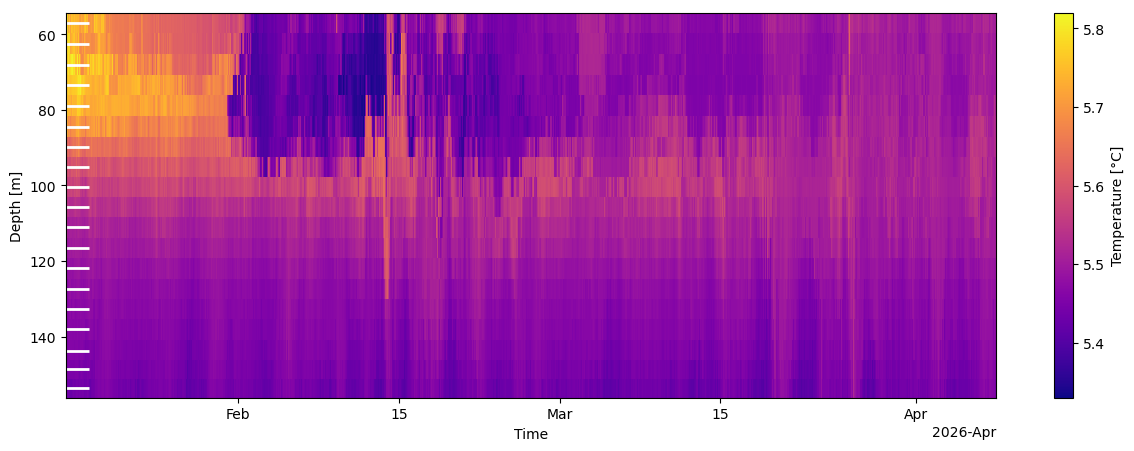

In [45]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [47]:
ds_chain = []
for ol in tqdm(oxygen_loggers, total=len(oxygen_loggers)):

    try:
        oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
        oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
        ds = oreader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)
    except FileNotFoundError:
        continue

ds_do = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/22 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


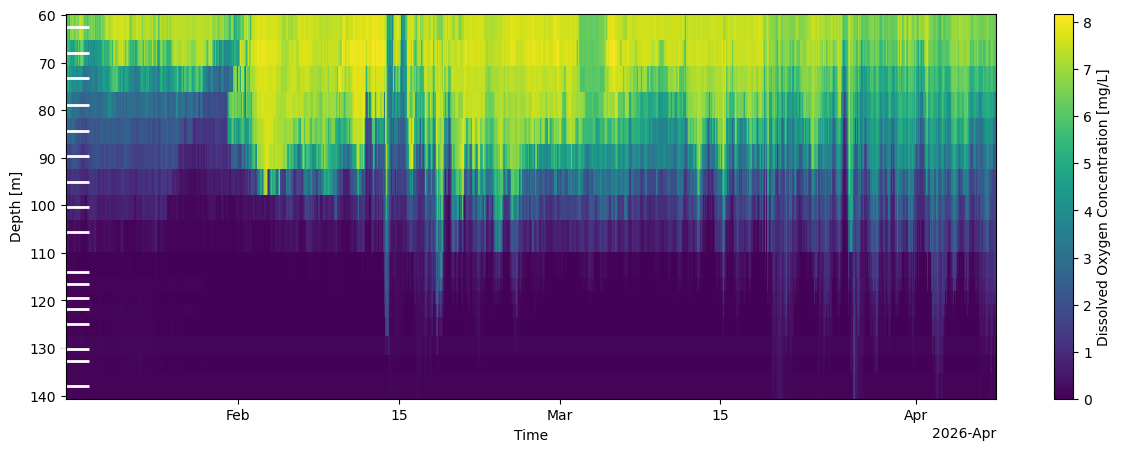

In [48]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZW

In [49]:
location = 'LZW'

In [50]:
mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

In [51]:
# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZW/L0\3U16576.000 ...


#### ADCP

In [66]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZW/L0\3U16576.000 ...


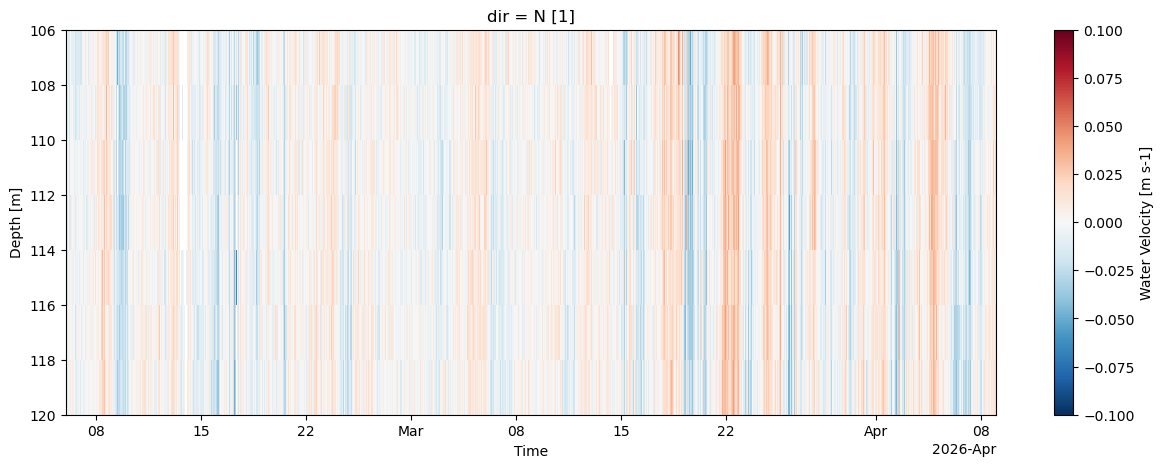

In [55]:
fig, ax = plt.subplots(figsize=(15, 5))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [60]:
ds_chain = []
for t in tqdm(thermistors, total=len(thermistors)):
    if t['serial_id'] != '82133':  # time dimension does not align
        treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
        treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/8 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


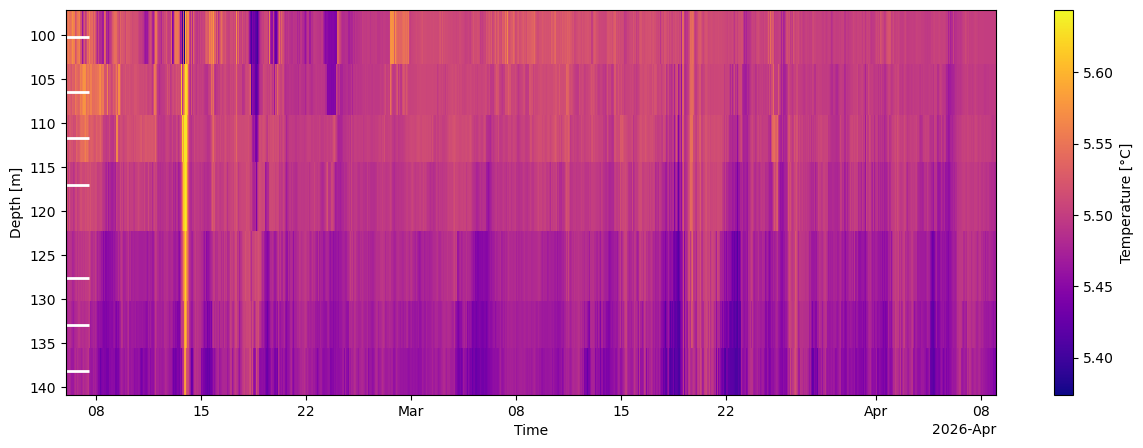

In [63]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [64]:
ds_chain = []
for ol in oxygen_loggers:
    serial_id = ol['serial_id']

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


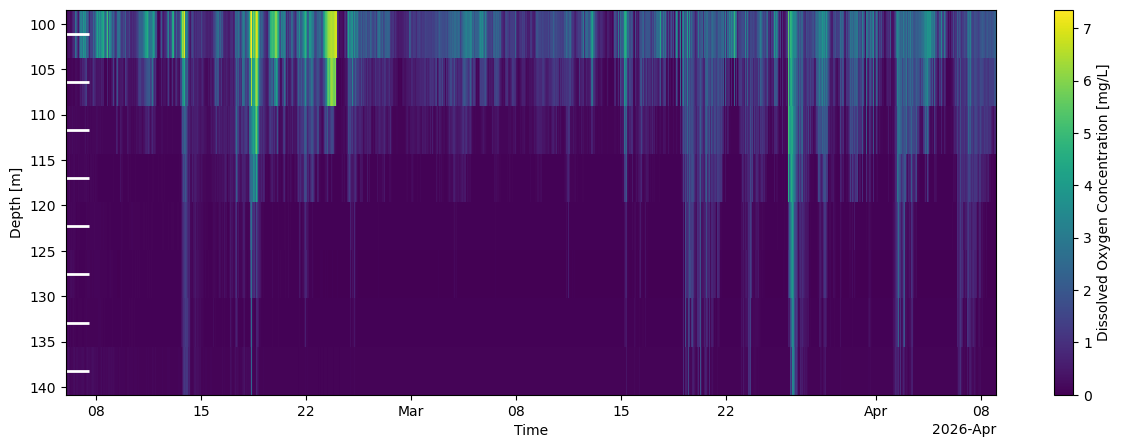

In [65]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZE

In [69]:
location = 'LZE'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

In [70]:
# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZE/L0\6U23656.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')
C:\Users\herremha\AppData\Local\Temp\ipykernel_32128\3092807462.py:9: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  depth_table = pd.merge(instruments, sensor_depths, how='outer')


#### ADCP

In [71]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds.depth.mean()


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZE/L0\6U23656.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')


<xarray.DataArray 'depth' ()> Size: 8B
array(120.)

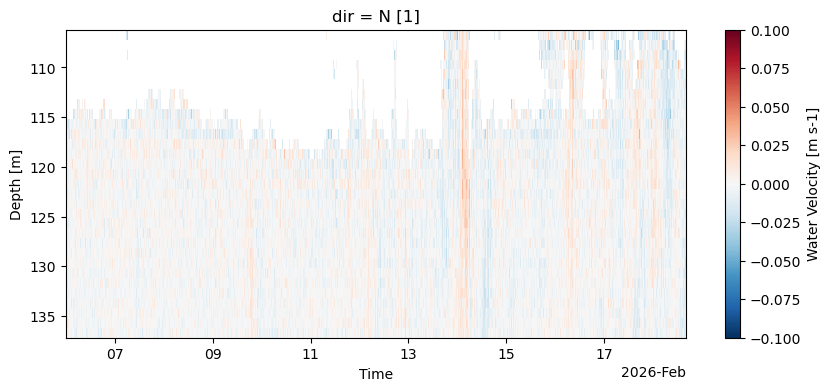

In [74]:
fig, ax = plt.subplots(figsize=(10, 4))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [75]:
ds_chain = []
for t in tqdm(thermistors, total=len(thermistors)):
    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
    ds = treader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/8 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


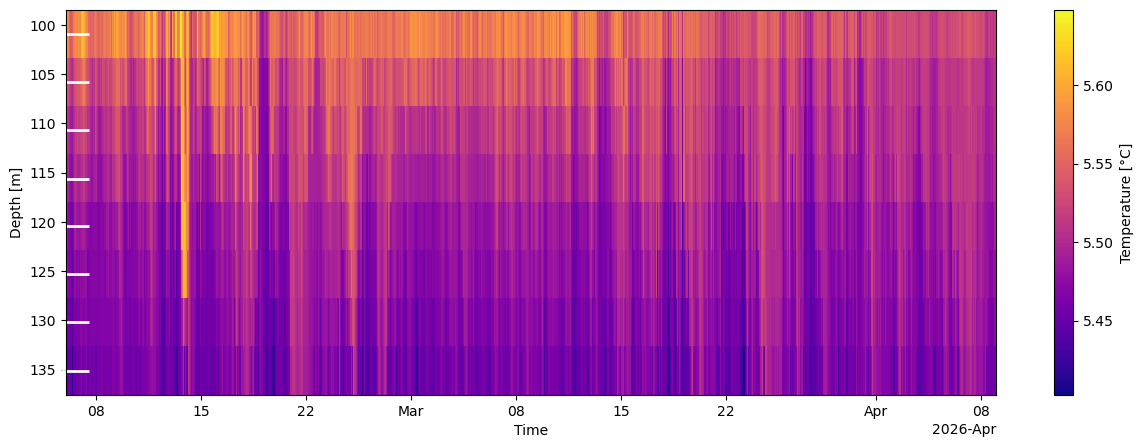

In [80]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [81]:
ds_chain = []
for ol in tqdm(oxygen_loggers, total=len(oxygen_loggers)):
    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/8 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


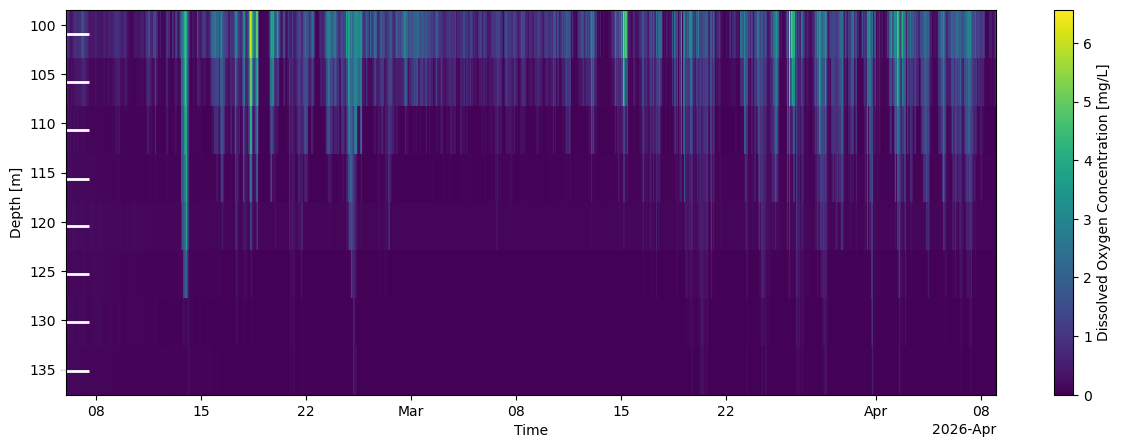

In [82]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()

### LZN

In [83]:
location = 'LZN'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
adcps = mreader.get_adcps()
thermistors = mreader.get_thermistors()
oxygen_loggers = mreader.get_oxygen_loggers()

In [84]:
# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZN/L0\3U420.000 ...


#### ADCP

In [94]:
adcp = adcps[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds.depth.mean()


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zug/2026/Mooring/20260409/LZN/L0\3U420.000 ...


<xarray.DataArray 'depth' ()> Size: 8B
array(133.01399231)

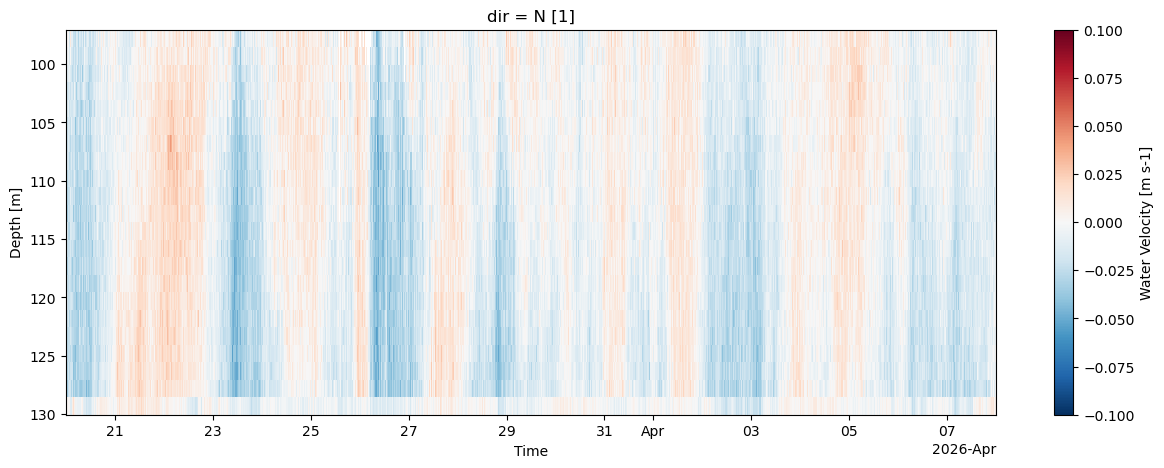

In [95]:
fig, ax = plt.subplots(figsize=(15, 5))

ds.vel.sel(dir='N').plot(cmap='RdBu_r', vmin=-0.1, vmax=0.1, ax=ax)

ax.set_xlabel('Time')
ax.set_ylabel('Depth [m]')
ax.invert_yaxis()
plt.show()

#### Thermistors

In [90]:
ds_chain = []
for t in tqdm(thermistors, total=len(thermistors)):
    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
    ds = treader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/9 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


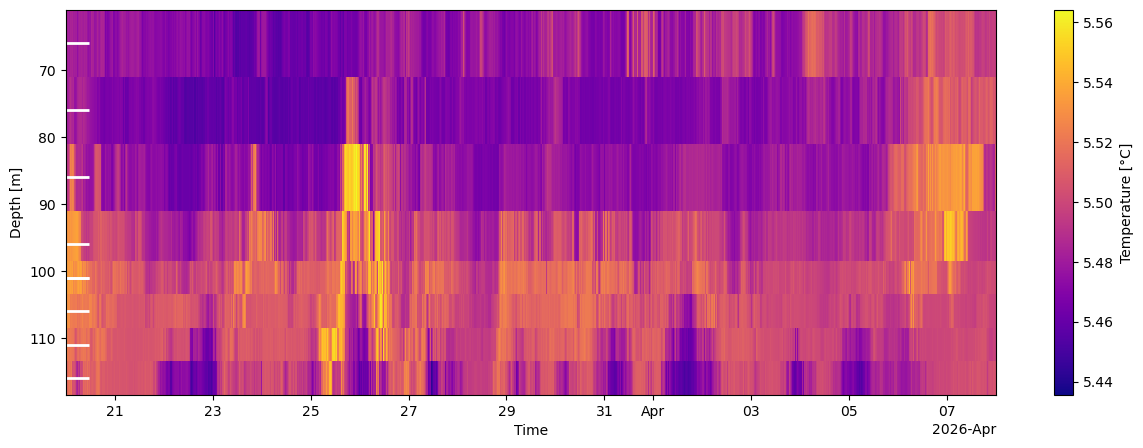

In [70]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_temp.temp.plot(cmap='plasma', ax=ax)
for d in ds_temp.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Temperature [°C]")

ax.invert_yaxis()
plt.show()

#### Oxygen loggers

In [91]:
ds_chain = []
for ol in tqdm(oxygen_loggers, total=len(oxygen_loggers)):
    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

  0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


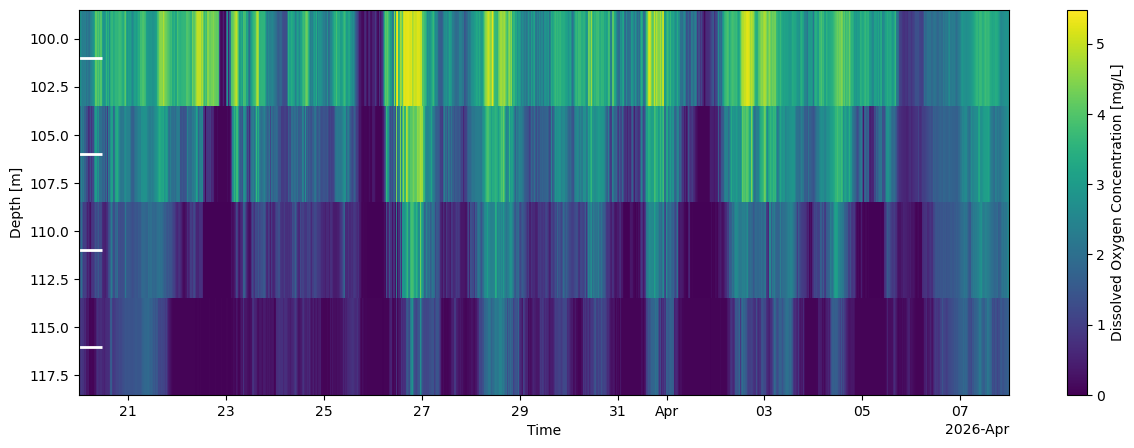

In [92]:
fig, ax = plt.subplots(figsize=(15, 5))
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, ax=ax)
for d in ds_do.depth:
    ax.plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax.get_yaxis_transform(), clip_on=False)

ax.set_xlabel("Time")
ax.set_ylabel('Depth [m]')
im.colorbar.set_label("Dissolved Oxygen Concentration [mg/L]")

ax.invert_yaxis()
plt.show()